# EDA ראשוני — דאטאסט קמעונאי ישראלי
**מטרה:** להכיר את הנתונים לפני שנבנה את הסוכנים

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# הגדרות תצוגה
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('ספריות נטענו בהצלחה!')

ספריות נטענו בהצלחה!


## 1. טעינת הדאטא

In [2]:
df = pd.read_csv('../data/raw/israeli_retail.csv', encoding='utf-8-sig')
print(f'גודל הדאטאסט: {df.shape[0]:,} שורות x {df.shape[1]} עמודות')
df.head()

גודל הדאטאסט: 10,000 שורות x 19 עמודות


,מספר_הזמנה,תאריך,שנה,חודש,יום_בשבוע,עונה,חג,רשת,עיר,אזור,קטגוריה,תת_קטגוריה,מוצר,כמות,מחיר_יחידה,הנחה_אחוז,מכירות_ש,רווח_ש,אחוז_רווח
0,IL-01001,2022-08-17,2022,8,רביעי,קיץ,NaN,חצי חינם,תל אביב,מרכז,ביגוד והנעלה,נשים,שמלת קיץ,3,126.65,0.15,379.95,138.64,36.5
1,IL-01002,2022-07-29,2022,7,שישי,קיץ,NaN,חצי חינם,באר שבע,דרום,בריאות ויופי,תרופות OTC,וויקס,7,24.90,0.00,174.30,55.05,31.6
2,IL-01003,2022-03-03,2022,3,חמישי,אביב,NaN,רמי לוי,ראשון לציון,מרכז,אלקטרוניקה,מטעני חשמל,סוללה ניידת,1,134.10,0.10,134.10,26.74,19.9
3,IL-01004,2023-02-12,2023,2,ראשון,חורף,NaN,חצי חינם,אשדוד,דרום,בריאות ויופי,ויטמינים,ויטמין C 1000,8,35.10,0.10,280.80,102.69,36.6
4,IL-01005,2023-07-24,2023,7,שני,קיץ,NaN,שופרסל,אשקלון,דרום,אלקטרוניקה,טלוויזיות,"LG 50""",5,2299.00,0.00,11495.00,1988.35,17.3


In [3]:
# סוגי עמודות + ערכים חסרים
print('סוגי עמודות:')
print(df.dtypes)
print(f'\nערכים חסרים: {df.isnull().sum().sum()}')

סוגי עמודות:
מספר_הזמנה        str
תאריך             str
שנה             int64
חודש            int64
יום_בשבוע         str
עונה              str
חג                str
רשת               str
עיר               str
אזור              str
קטגוריה           str
תת_קטגוריה        str
מוצר              str
כמות            int64
מחיר_יחידה    float64
הנחה_אחוז     float64
מכירות_ש      float64
רווח_ש        float64
אחוז_רווח     float64
dtype: object

ערכים חסרים: 9670


## 2. סטטיסטיקות בסיסיות

In [4]:
print('=== סיכום כספי ===')
print(f"סה\"כ מכירות:  ₪{df['מכירות_ש'].sum():>12,.0f}")
print(f"סה\"כ רווח:    ₪{df['רווח_ש'].sum():>12,.0f}")
print(f"אחוז רווח:    {df['רווח_ש'].sum()/df['מכירות_ש'].sum()*100:.1f}%")
print(f"\nממוצע עסקה:  ₪{df['מכירות_ש'].mean():>9,.1f}")
print(f"חציון עסקה:  ₪{df['מכירות_ש'].median():>9,.1f}")

=== סיכום כספי ===
סה"כ מכירות:  ₪  19,507,138
סה"כ רווח:    ₪   3,890,819
אחוז רווח:    19.9%

ממוצע עסקה:  ₪  1,950.7
חציון עסקה:  ₪    245.0


## 3. מכירות לפי קטגוריה

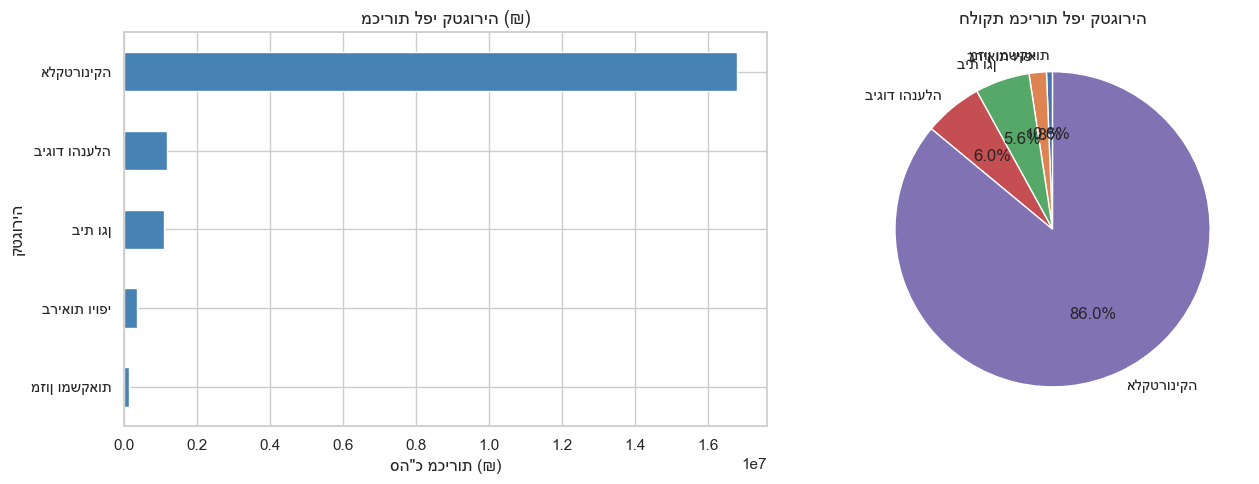

In [5]:
cat_sales = df.groupby('קטגוריה')['מכירות_ש'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף 1 — מכירות לפי קטגוריה
cat_sales.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('מכירות לפי קטגוריה (₪)', fontsize=13)
axes[0].set_xlabel('סה"כ מכירות (₪)')

# גרף 2 — אחוז מכירות (פאי)
cat_sales.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('חלוקת מכירות לפי קטגוריה', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/chart_categories.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. מכירות לפי רשת

In [6]:
chain_stats = df.groupby('רשת').agg(
    מכירות=('מכירות_ש', 'sum'),
    רווח=('רווח_ש', 'sum'),
    עסקאות=('מספר_הזמנה', 'count')
).round(0)
chain_stats['אחוז_רווח'] = (chain_stats['רווח'] / chain_stats['מכירות'] * 100).round(1)
chain_stats.sort_values('מכירות', ascending=False)

,מכירות,רווח,עסקאות,אחוז_רווח
רשת,,,,
ויקטורי,3782599.0,749604.0,1691,19.8
מגה,3292592.0,656892.0,1669,20.0
חצי חינם,3272682.0,661622.0,1741,20.2
שופרסל,3185163.0,626009.0,1659,19.7
יינות ביתן,3062559.0,611361.0,1672,20.0
רמי לוי,2911544.0,585331.0,1568,20.1


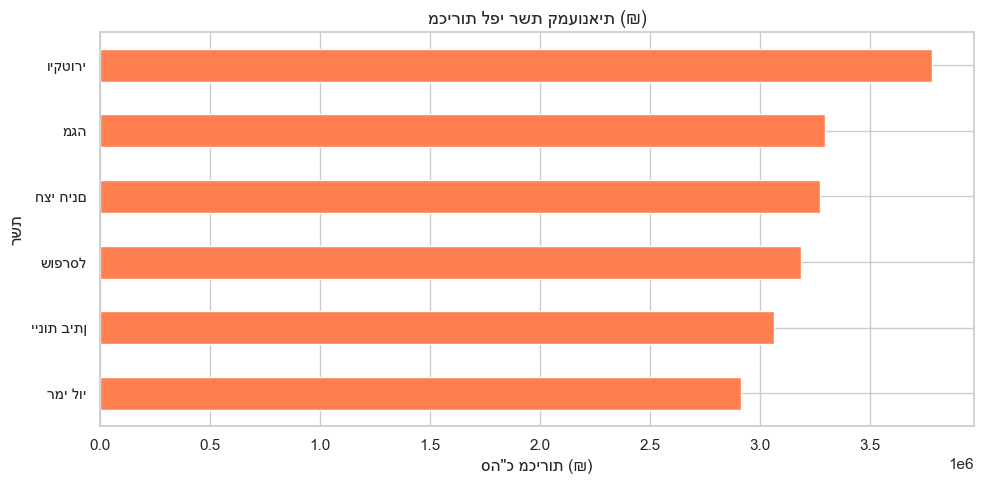

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
chain_stats['מכירות'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('מכירות לפי רשת קמעונאית (₪)', fontsize=13)
ax.set_xlabel('סה"כ מכירות (₪)')
plt.tight_layout()
plt.savefig('../data/processed/chart_chains.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. מכירות לפי חודש (טרנד)

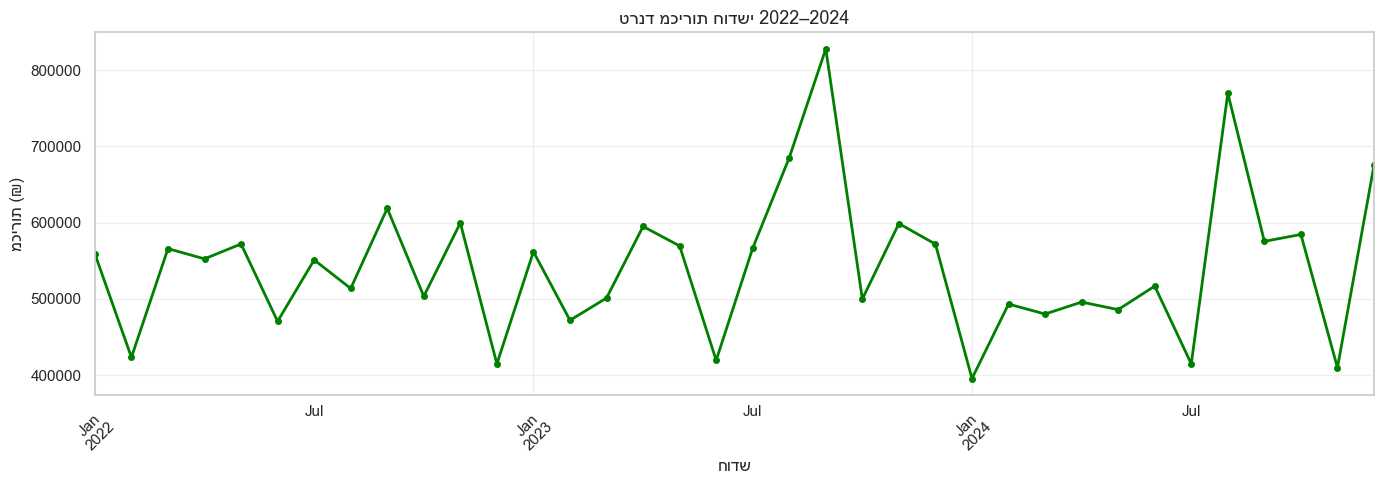

In [8]:
df['תאריך'] = pd.to_datetime(df['תאריך'])
monthly = df.groupby(df['תאריך'].dt.to_period('M'))['מכירות_ש'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, color='green', linewidth=2, marker='o', markersize=4)
ax.set_title('טרנד מכירות חודשי 2022–2024', fontsize=13)
ax.set_xlabel('חודש')
ax.set_ylabel('מכירות (₪)')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/chart_monthly_trend.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. השפעת ימי השבוע

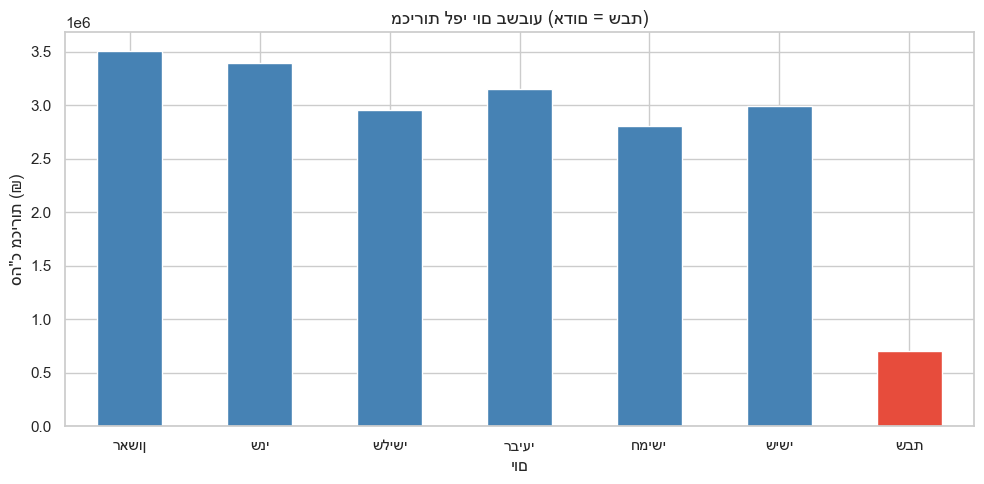

In [9]:
day_order = ['ראשון', 'שני', 'שלישי', 'רביעי', 'חמישי', 'שישי', 'שבת']
day_sales = df.groupby('יום_בשבוע')['מכירות_ש'].sum().reindex(day_order)

colors = ['#e74c3c' if d == 'שבת' else 'steelblue' for d in day_order]
fig, ax = plt.subplots(figsize=(10, 5))
day_sales.plot(kind='bar', ax=ax, color=colors)
ax.set_title('מכירות לפי יום בשבוע (אדום = שבת)', fontsize=13)
ax.set_xlabel('יום')
ax.set_ylabel('סה"כ מכירות (₪)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/chart_weekday.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. השפעת חגים

In [10]:
holiday_sales = df[df['חג'] != ''].groupby('חג')['מכירות_ש'].sum().sort_values(ascending=False)
regular_avg   = df[df['חג'] == '']['מכירות_ש'].mean()

print(f'ממוצע מכירות ביום רגיל: ₪{regular_avg:,.0f}')
print('\nמכירות לפי חג:')
print(holiday_sales.to_string())

ממוצע מכירות ביום רגיל: ₪nan

מכירות לפי חג:
חג
ראש השנה     613033.25
חנוכה        279369.03
פורים        214098.18
פסח          192867.72
סוכות         89213.46
שמחת תורה     37089.73


## 8. מפת חום — קטגוריה לפי עיר

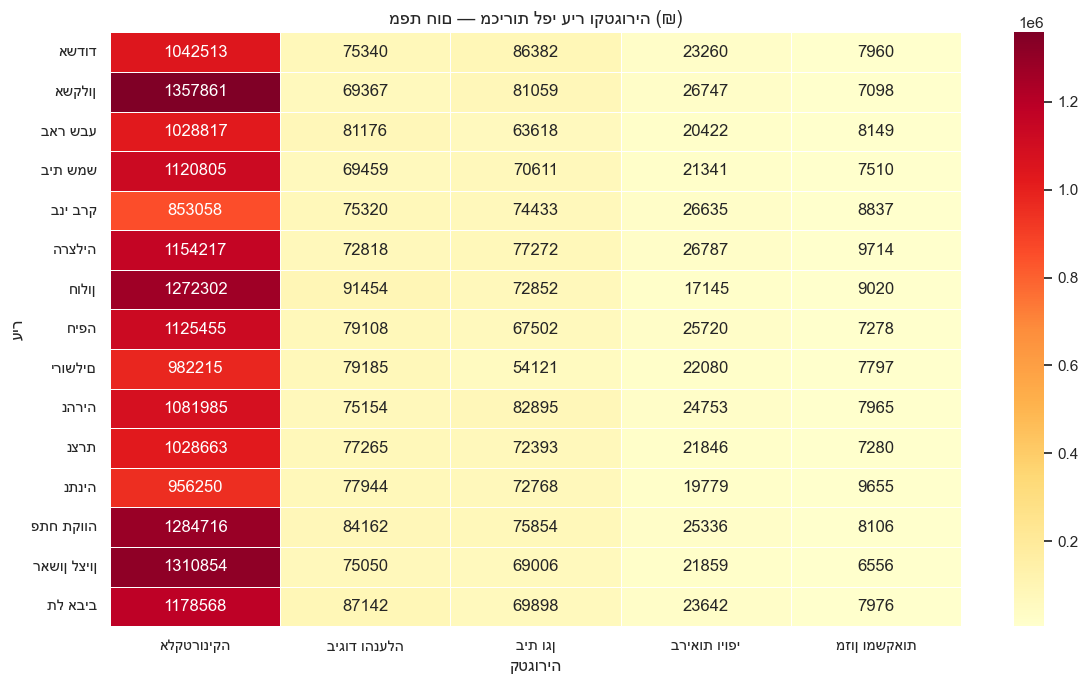

In [11]:
pivot = df.pivot_table(values='מכירות_ש', index='עיר', columns='קטגוריה', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('מפת חום — מכירות לפי עיר וקטגוריה (₪)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/chart_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. תובנות ראשוניות

✍️ **כתוב כאן את התובנות שלך אחרי שראית את הגרפים:**

1. הקטגוריה המובילה היא: ___
2. הרשת עם הכי הרבה מכירות: ___
3. החודש הכי חזק בשנה: ___
4. ההשפעה הכי גדולה על מכירות: ___
5. תובנה מפתיעה שגיליתי: ___